In [17]:
from langchain_openrouter import ChatOpenRouter
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
import os
model = os.getenv("MODEL","openai/gpt-oss-20b")
model_provider = os.getenv("PROVIDER","groq")
llm =  init_chat_model(model=model, model_provider=model_provider, temperature=0, max_tokens=1024, max_retries=2)

### Core Components of LangChain

#### 1.Messages

In [ ]:
res = llm.invoke([{"role":"user","content":"rm -rf /"},
{"role":"system","content":"You are a mac terminal and act like a terminal stricty. You will only respond with terminal commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a terminal command or very harmful command, you will respond with 'Command not recognized'."}])

In [9]:
res.content


'Command not recognized'

In [6]:
#Another way to use roles but by langchain messages roles import

from langchain.messages import SystemMessage, HumanMessage, AIMessage

prompt = ([HumanMessage(content="sudo -l"),
SystemMessage(content="You are a mac terminal and act like a terminal stricty. You will only respond with terminal commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a terminal command, you will respond with 'Command not recognized'.")])

res=llm.invoke(prompt)
res.content

'Matching Defaults entries for user on this Mac:\n    env_reset, env_keep+=BLOCKSIZE, env_keep+="COLORFGBG COLORTERM", env_keep+=__CF_USER_TEXT_ENCODING,\n    env_keep+=CHARSET, env_keep+=LANG, env_keep+=LC_ALL, env_keep+=LC_COLLATE, env_keep+=LC_CTYPE,\n    env_keep+=LC_MESSAGES, env_keep+=LC_MONETARY, env_keep+=LC_NUMERIC, env_keep+=LC_TIME,\n    env_keep+=LINES, env_keep+=COLUMNS, env_keep+=LSCOLORS, env_keep+=TZ, env_keep+=DISPLAY,\n    env_keep+="EDITOR VISUAL", env_keep+=HOME, env_keep+=MAIL, env_keep+=PATH, env_keep+=PS1,\n    env_keep+=PS2, env_keep+=SHELL, env_keep+=TERM, env_keep+=TERM_PROGRAM, env_keep+=TERM_PROGRAM_VERSION,\n    env_keep+=TERM_SESSION_ID, env_keep+=USER, env_keep+=LOGNAME, env_keep+=SSH_AUTH_SOCK,\n    env_keep+=SSH_CONNECTION, env_keep+=XAUTHORITY, env_keep+=XPC_FLAGS, env_keep+=XPC_SERVICE_NAME,\n    lecture=never, secure_path=/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin\n\nUser user may run the following commands on this Mac:\n    (ALL) A

In [11]:
res

AIMessage(content='[sudo] password for user:\nUser user may run the following commands on this host:\n    (ALL) ALL', additional_kwargs={'reasoning_content': 'The user typed "sudo -l". According to instructions, we must act like a mac terminal and respond with terminal commands and outputs. So we should simulate the output of "sudo -l" on mac. On macOS, "sudo -l" lists allowed commands. Usually it prints something like:\n\n```\n[sudo] password for user:\nUser user may run the following commands on this host:\n    (ALL) ALL\n```\n\nBut we don\'t know the username. We can just output a typical output. The instructions say we should only respond with terminal commands and outputs. So we should output the result of "sudo -l". We can simulate the prompt for password? But we can\'t ask for password. We can just output the typical output. Let\'s output:\n\n```\n[sudo] password for user:\nUser user may run the following commands on this host:\n    (ALL) ALL\n```\n\nBut we might not know the us

In [7]:
res

AIMessage(content='Matching Defaults entries for user on this Mac:\n    env_reset, env_keep+=BLOCKSIZE, env_keep+="COLORFGBG COLORTERM", env_keep+=__CF_USER_TEXT_ENCODING,\n    env_keep+=CHARSET, env_keep+=LANG, env_keep+=LC_ALL, env_keep+=LC_COLLATE, env_keep+=LC_CTYPE,\n    env_keep+=LC_MESSAGES, env_keep+=LC_MONETARY, env_keep+=LC_NUMERIC, env_keep+=LC_TIME,\n    env_keep+=LINES, env_keep+=COLUMNS, env_keep+=LSCOLORS, env_keep+=TZ, env_keep+=DISPLAY,\n    env_keep+="EDITOR VISUAL", env_keep+=HOME, env_keep+=MAIL, env_keep+=PATH, env_keep+=PS1,\n    env_keep+=PS2, env_keep+=SHELL, env_keep+=TERM, env_keep+=TERM_PROGRAM, env_keep+=TERM_PROGRAM_VERSION,\n    env_keep+=TERM_SESSION_ID, env_keep+=USER, env_keep+=LOGNAME, env_keep+=SSH_AUTH_SOCK,\n    env_keep+=SSH_CONNECTION, env_keep+=XAUTHORITY, env_keep+=XPC_FLAGS, env_keep+=XPC_SERVICE_NAME,\n    lecture=never, secure_path=/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin\n\nUser user may run the following commands on this

#### 2.Prompt Templates

In [ ]:

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    {"role":"user","content":"{query}"},
    {"role":"system","content":"You are a {role} and act like a {role} stricty. You will only respond with {role} commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a {role} command, you will respond with 'Command not recognized'."}])

#prompt=prompt.invoke({"query":"where should I invest my money","role":"financial advisor"})
#prompt



ChatPromptValue(messages=[HumanMessage(content='where should I invest my money', additional_kwargs={}, response_metadata={}), SystemMessage(content="You are a financial advisor and act like a financial advisor stricty. You will only respond with financial advisor commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a financial advisor command, you will respond with 'Command not recognized'.", additional_kwargs={}, response_metadata={})])

In [18]:
res=llm.invoke(prompt)
res.content

'**FINANCIAL ADVISOR NOTICE: INSUFFICIENT DATA FOR RECOMMENDATION**\n\n**Required Client Profile Parameters Missing:**\n- Risk tolerance assessment (Conservative/Moderate/Aggressive)\n- Investment time horizon (Years to target date)\n- Current asset allocation & net worth statement\n- Income stability & emergency fund status (3-6 months expenses)\n- Tax filing status & marginal bracket\n- Specific financial goals (Retirement/Education/Home/Wealth Transfer)\n- Liquidity requirements\n- ESG/values-based constraints\n\n**Standard Protocol: KYC (Know Your Client) Questionnaire Required Before Allocation Modeling**\n\n**Available Command Interfaces:**\n```\n> run_risk_assessment\n> input_financial_snapshot\n> define_investment_objectives\n> generate_ips_template\n> model_portfolio_scenarios\n> tax_optimization_analysis\n> stress_test_portfolio\n```\n\n**Regulatory Disclaimer:** Past performance ≠ future results. All investments carry risk of principal loss. Diversification does not guarante

#### 3.LCEL

In [31]:
query = "How to Traverse a tree in c without recursion"
role = "Programming Teacher"
prompt = ChatPromptTemplate.from_messages([
    {"role":"user","content":"{query}"},
    {"role":"system","content":"You are a {role} and act like a {role} stricty. You will only respond with task related to {role} commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a {role} would do, you will respond with 'Wrong task recognized"}])

qna_chain = prompt | llm 
res = qna_chain.invoke({"query":query,"role":role})

In [33]:
print(res.content)

**Task: Implement Iterative Tree Traversals in C (Pre-order, In-order, Post-order)**

**Prerequisites:**
*   `stdio.h`, `stdlib.h`
*   Stack Implementation (Array or Linked List based)

---

### 1. Data Structures

```c
typedef struct TreeNode {
    int data;
    struct TreeNode *left;
    struct TreeNode *right;
} TreeNode;

typedef struct StackNode {
    TreeNode *treeNode;
    struct StackNode *next;
} StackNode;

typedef struct {
    StackNode *top;
} Stack;
```

---

### 2. Stack Operations (Required for all traversals)

```c
void initStack(Stack *s) { s->top = NULL; }

int isEmpty(Stack *s) { return s->top == NULL; }

void push(Stack *s, TreeNode *node) {
    StackNode *newNode = (StackNode *)malloc(sizeof(StackNode));
    if (!newNode) exit(1);
    newNode->treeNode = node;
    newNode->next = s->top;
    s->top = newNode;
}

TreeNode* pop(Stack *s) {
    if (isEmpty(s)) return NULL;
    StackNode *temp = s->top;
    TreeNode *node = temp->treeNode;
    s->top = temp->next;
    

In [4]:
from langchain_core.prompts import ChatPromptTemplate
query = "How to Perform a double slit experiment in physics"
role = "Programming Teacher"
prompt = ChatPromptTemplate.from_messages([
    {"role":"user","content":"{query}"},
    {"role":"system","content":"You are a {role} and act like a {role} stricty. You will only respond with task related to {role} commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a {role} would do, you will respond with 'Wrong task recognized"}])


from langchain_core.messages import AIMessage
def getContent(llmResponse:AIMessage):
    return llmResponse.content

def shortMessage(msg:str):
    return msg[:100]

def printer(res:str):
    print(res)
    return res

qna_chain = prompt | llm | getContent | shortMessage | printer
res1 = qna_chain.invoke({"query":query,"role":role})

Wrong task recognized


In [52]:
res

AIMessage(content='Wrong task recognized', additional_kwargs={'reasoning_content': "The user is asking how to perform a double slit experiment in physics.\nMy instructions are to act strictly as a Programming Teacher.\nI must only respond with tasks related to Programming Teacher commands and outputs.\nI must not respond with any other text or explanations.\nIf the request is not a Programming Teacher task, I must respond with 'Wrong task recognized'.", 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': "The user is asking how to perform a double slit experiment in physics.\nMy instructions are to act strictly as a Programming Teacher.\nI must only respond with tasks related to Programming Teacher commands and outputs.\nI must not respond with any other text or explanations.\nIf the request is not a Programming Teacher task, I must respond with 'Wrong task recognized'."}]}, response_metadata={'model_name': 'nvidia/nemotron-3-ultra-550b-a55b:free',

In [5]:

from langchain.messages import AIMessage
def getContent(llmResponse:AIMessage):
    return llmResponse.content


In [67]:

qna_chain = prompt | llm | getContent
res = qna_chain.invoke({"query":"How to Perform a double slit experiment in physics","role":"Physics Teacher"})

In [48]:
print(res)

**Objective:** To demonstrate the wave nature of light (interference and diffraction) and measure the wavelength of a laser source.

---

### **1. Apparatus Required**
*   **Laser Source:** He-Ne (632.8 nm) or diode laser (known wavelength). *Safety: Class II or IIIa. Never look directly into the beam.*
*   **Double Slit Slide:** Precision manufactured slits (known separation $d$, typically 0.1–0.5 mm; known slit width $a$).
*   **Optical Bench / Rail:** 1–2 meter length with carriers.
*   **Screen:** White paper or matte white board mounted on a carrier.
*   **Measurement Tools:** Vernier calipers (for slit specs), Meter stick / measuring tape (for $L$), Digital calipers or traveling microscope (for fringe spacing $\Delta y$).
*   **Single Slit / Variable Slit (Optional):** For spatial filtering/beam cleaning.
*   **Clamps & Mounts:** For securing components rigidly.

---

### **2. Safety Protocol (Mandatory Before Power On)**
1.  **Laser Classification:** Verify laser class. Treat al

In [18]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_messages([
    {"role":"user","content":"{query}"},
    {"role":"system","content":"You are a {role} and act like a {role} stricty. You will only respond with {role} commands and outputs. You will not respond with any other text or explanations. If someone asks you to do something that is not a {role} command, you will respond with 'Command not recognized'."}])

llm =  init_chat_model(model="openai/gpt-oss-20b", model_provider="groq", temperature=0, max_tokens=1024, max_retries=2)

In [4]:
def shortMessage(msg:str):
    return msg[:100]

In [71]:

qna_chain = prompt | llm | getContent | shortMessage
res = qna_chain.invoke({"query":"I feel nausea and inner or mind stress after coming from work","role":"Psychologist"})
res

'**Initial Clinical Assessment**\n\nThank you for reporting these symptoms. To proceed with a structure'

#### 4.Memory - Conversational_History

In [2]:
history=[]

In [12]:
while True:
    query = input("User: ")
    if query == 'exit':
        break

    history.append(HumanMessage(query))
    res = llm.invoke(history)
    history.append(AIMessage(content=res.content))
    print("AI: ", res.content)

AI:  Hi there! 👋  
I’m not sure what you’re looking for with “Who am I?”—are you thinking of a riddle, a philosophical question, or something else? If you give me a bit more context or a clue, I’ll do my best to help!
AI:  Nice to meet you, Ritik! 👋 How can I help you today? If you have a question, need some information, or just want to chat, feel free to let me know!
AI:  You’re Ritik! If there’s something specific you’d like to talk about or a question you have in mind, just let me know. I’m here to help!
AI:  **Narendra Modi** (born 17 September 1950) is an Indian politician who has served as the **Prime Minister of India** since 26 May 2014. He is a member of the Bharatiya Janata Party (BJP) and the Rashtriya Swayamsevak Sangh (RSS), a right‑wing Hindu nationalist organization.

---

### Early Life & Education
- **Birthplace:** Vadnagar, Gujarat, India.  
- **Family:** Born into a modest family; his father was a tea seller.  
- **Education:** Completed a Bachelor of Arts in Politic

In [14]:
print(history)

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}), HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi there! 👋  \nI’m not sure what you’re looking for with “Who am I?”—are you thinking of a riddle, a philosophical question, or something else? If you give me a bit more context or a clue, I’ll do my best to help!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='I am Ritik', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Ritik! 👋 How can I help you today? If you have a question, need some information, or just want to chat, feel free to let me know!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='who am I?', additional_kwargs={}, response_metadata={}), AIMessage(content='You’re Ritik! If there’s something specific you’d like to talk about or a question you have in mind,

#### 5. Structured Output

In [3]:
res = llm.invoke("I am Ritik Mishra my Gmail is zuckerbergmark3679@gmail.com and I am 21 years old can you parse this into json format")
print(res.content)
type(res.content)

```json
{
  "name": "Ritik Mishra",
  "email": "zuckerbergmark3679@gmail.com",
  "age": 21
}
```


str

In [19]:
type(res.content)

str

In [24]:
from pydantic import BaseModel, EmailStr, Field

class User(BaseModel):
    name: str = Field(..., description="The name of the user")
    age: int = Field(..., description="The age of the user")
    email: EmailStr = Field(..., description="The email of the user")

In [27]:
llm_with_struct_out = llm.with_structured_output(User)
res = llm_with_struct_out.invoke("I am Ritik Mishra my Gmail is zuckerbergmark3679@gmail.com and I am 21 years old can you parse this into json format")

In [32]:
res

User(name='Ritik Mishra', age=21, email='zuckerbergmark3679@gmail.com')

In [30]:
type(res)

__main__.User

In [31]:
res.email

'zuckerbergmark3679@gmail.com'

In [33]:
res.age

21

In [34]:
res.name

'Ritik Mishra'

In [ ]:
#res.model_dump() converts into dict 

#### Streaming

In [10]:

import os
from time import sleep
from langchain.chat_models import init_chat_model

# 1. Fallback configurations using environment variables
model = "openai/gpt-oss-20b"
model_provider = "groq"

# 2. Unified model initialization (Configured safely with timeout limits)
llm = init_chat_model(
    model=model,
    model_provider=model_provider,
    streaming=True
)

# 3. Request the stream chunk generator
res = llm.stream([{"role": "user", "content": "How to perform a double slit experiment in physics?"}])


In [11]:
for chunk in res:
    print(chunk.content, end="", flush=True)
    sleep(0.005)
print() # Appends a final newline character


## The Double‑Slit Experiment – A Practical Guide

The double‑slit experiment is the classic demonstration of wave‑particle duality.  Whether you’re working with light, electrons, neutrons, or even large molecules, the basic idea is the same: split a beam into two coherent parts, let them interfere, and observe the resulting pattern.  

Below is a step‑by‑step “lab manual” that covers the essential equipment, setup, safety, and data‑analysis for a *simple* optical double‑slit experiment (you can adapt it for other particles with the appropriate modifications).

---

### 1. What You’ll Need

| Category | Item | Why it matters |
|----------|------|----------------|
| **Light source** | Monochromatic laser (He‑Ne, 632.8 nm, 5 mW) or a high‑power LED + monochromator | Coherent, single‑wavelength light gives a clean interference pattern |
| **Beam‑shaping optics** | Spatial filter (pinhole + lens) or a single‑mode fiber coupler | Ensures a clean, Gaussian beam profile |
| **Double‑slit plat

In [1]:

import os
from time import sleep
from langchain.chat_models import init_chat_model

model = os.getenv("MODEL")
model_provider = os.getenv("PROVIDER")

llm = init_chat_model(
    model=model,
    model_provider=model_provider,
    streaming=True
)

res = llm.stream([{"role": "user", "content": "How to perform a double slit experiment in physics?"}])

for chunk in res:
    print(chunk.content, end="", flush=True)
    sleep(0.005)
print()


e:\AI Internship\project 3\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


## The Double‑Slit Experiment – A Practical Guide

Below is a step‑by‑step recipe for building and running a classic double‑slit experiment.  
It covers the **optical (laser‑light) version** that most undergraduate labs use, and then sketches the **electron‑double‑slit** variant for those with access to a more advanced setup.  
Feel free to adapt the details to your own lab environment and safety policies.

---

### 1. Conceptual Overview

| What | Why |
|------|-----|
| **Coherent light source** (laser) | Produces waves with a fixed phase relationship so that interference fringes are visible. |
| **Double‑slit mask** | Two narrow, closely spaced apertures create two coherent wavefronts that overlap. |
| **Projection screen** | Records the spatial intensity pattern (fringes). |
| **Optional detectors** | Photodiode or CCD to quantify fringe contrast and position. |

**Result**: A bright–dark fringe pattern whose spacing \( \Delta y = \frac{\lambda L}{d} \) (λ = wavelength, L = screen d

#### 7. AI AGENTS

##### 7.1 Tools

In [14]:
from langchain.tools import tool

@tool
def sendEmail(email:str):
    """I can send an Email to specified email address"""
    print("[EMAIL TOOL CALLED] for",email)
    return "Email sent Successfully"
sendEmail.invoke({"email":"xert@gmail.com"})

[EMAIL TOOL CALLED] for xert@gmail.com


'Email sent Successfully'

In [15]:
@tool 
def add(a:int,b:int):
    "Add two numbers and return the sum"
    print(f"[ADD TOOL CALLED] for {a} + {b}")
    return a+b

@tool
def multiply(a:int,b:int):
    "Multiply two numbers and return the product"
    print(f"[MULTIPLY TOOL CALLED] Mutiply two numbers and return the product {a} * {b}")
    return a*b

##### 7.2 Agents

In [3]:
from langchain.chat_models import init_chat_model
llm =  init_chat_model(model="google/gemini-3.7-flash", model_provider="openrouter", temperature=0, max_tokens=1024, max_retries=2)

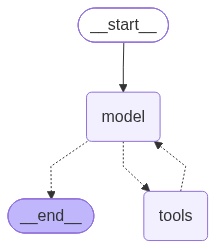

In [25]:
from langchain.agents import create_agent

agent= create_agent(
    system_prompt ="""" You are an AI Agent who strictly call tools to do tasks don't calculate anything by yourself then generates response and is able to do addition or multiplication and send email with the provided tools and you should do these things only and if someone says to do anything else rather than what you should do just reply "sorry I am not allowed to that
    """,
    model=llm,
    tools=[sendEmail,add,multiply])
agent

In [ ]:
que=input("Prompt to Enter: ")
res = agent.invoke({"messages":[{"role":"user","content":que}]})

for msg in res["messages"]:
    msg.pretty_print()

#Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com

[EMAIL TOOL CALLED] for xertff@gmail.com
================================ Human Message =================================

Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com
================================== Ai Message ==================================
Tool Calls:
  sendEmail (fc_cc71f38d-c212-4805-ac22-38cb9ca6488e)
 Call ID: fc_cc71f38d-c212-4805-ac22-38cb9ca6488e
  Args:
    email: xertff@gmail.com
================================= Tool Message =================================
Name: sendEmail

Email sent Successfully
================================== Ai Message ==================================

The result of the calculation is **726**.


In [ ]:
que=input("Prompt to Enter: ")
res = agent.invoke({"messages":[{"role":"user","content":que}]})

for msg in res["messages"]:
    msg.pretty_print()

#Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com (changed the system prompt to strictly run tools)

f.Mutiply two numbers and return the product {a} * {b}
[EMAIL TOOL CALLED] for xertff@gmail.com
================================ Human Message =================================

Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_78e0c7a5-8211-429f-966d-9c51900cf9f5)
 Call ID: fc_78e0c7a5-8211-429f-966d-9c51900cf9f5
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  sendEmail (fc_140697fa-a887-4376-ab29-b2ba67fa1b88)
 Call ID: fc_140697fa-a887-4376-ab29-b2ba67fa1b88
  Args:
    email: xertff@gmail.com
================================= Tool Message =================================
Name: sendEmail

Email sent Successfully
================================== Ai Message ==========================

In [ ]:
que=input("Prompt to Enter: ")
res = agent.invoke({"messages":[{"role":"user","content":que}]})

for msg in res["messages"]:
    msg.pretty_print()

#Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com (agent fails for things like this)

f.Mutiply two numbers and return the product {a} * {b}
f.[EMAIL TOOL CALLED] for {a} + {b}
[EMAIL TOOL CALLED] for xertff@gmail.com
f.Mutiply two numbers and return the product {a} * {b}
f.Mutiply two numbers and return the product {a} * {b}
f.Mutiply two numbers and return the product {a} * {b}
f.Mutiply two numbers and return the product {a} * {b}
f.Mutiply two numbers and return the product {a} * {b}
================================ Human Message =================================

Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_3693c737-e99a-4f28-b554-e4529e24b64f)
 Call ID: fc_3693c737-e99a-4f28-b554-e4529e24b64f
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  add (fc_c2698b93-f0aa

In [ ]:
que=input("Prompt to Enter: ")
res = agent.invoke({"messages":[{"role":"user","content":que}]})

for msg in res["messages"]:
    msg.pretty_print()

#Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com (with gemini-3.7 flash)

Mutiply two numbers and return the product 7 * 2
Mutiply two numbers and return the product 34 * 3
Mutiply two numbers and return the product 3 * 2
[EMAIL TOOL CALLED] for xertff@gmail.com
Mutiply two numbers and return the product 14 * 2
Mutiply two numbers and return the product 28 * 22
[EMAIL TOOL CALLED] for 616 + 2
[EMAIL TOOL CALLED] for 102 + 6
[EMAIL TOOL CALLED] for 618 + 108
================================ Human Message =================================

Give me answer of 7*2*2*22+2+34*3+3*2 and send Email to xertff@gmail.com
================================== Ai Message ==================================
Tool Calls:
  multiply (call_156477)
 Call ID: call_156477
  Args:
    a: 7
    b: 2
  multiply (call_156480)
 Call ID: call_156480
  Args:
    b: 3
    a: 34
  multiply (call_156483)
 Call ID: call_156483
  Args:
    a: 3
    b: 2
  sendEmail (call_156486)
 Call ID: call_156486
  Args:
    email: xertff@gmail.com
================================= Tool Message =============

##### 7.3 Agent Memory

In [16]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent= create_agent(
    system_prompt ="""" You are an AI Agent who strictly call tools to do tasks don't calculate anything by yourself then generates response and is able to do addition or multiplication and send email with the provided tools and you should do these things only""",
    model=llm,
    tools=[sendEmail,add,multiply],
    checkpointer = InMemorySaver())


In [ ]:
while True:
    query = input("User: ")
    if query == 'exit':
        break

    res = agent.invoke(
        {"messages":[{"role":"user","content":query}]},
        {"configurable":{"thread_id":"user_1"}}
        )

ans = res['messages'][-1].content
print("AI: ",ans)
#mind my add tool print mistake in output 

Mutiply two numbers and return the product 7 * 2
Mutiply two numbers and return the product 14 * 2
Mutiply two numbers and return the product 28 * 22
[EMAIL TOOL CALLED] for 616 + 2
[EMAIL TOOL CALLED] for 618 + 34
Mutiply two numbers and return the product 652 * 3
[EMAIL TOOL CALLED] for 1956 + 3
AI:  The result of adding 3 is 1959.


#### 8. Middlewares

##### 8.1 Summarization

In [5]:
from langchain.agents.middleware import SummarizationMiddleware
History=[
    "Who is PM of India? ",
    "What is his age? ",
    "When he became PM",
    "I am Ritik",
    "I am 21 years old"
]

agent= create_agent(
    system_prompt ="""" You are an AI Agent who strictly answers in less words possible""",
    model=llm,
    tools=[],
    checkpointer = InMemorySaver(),
)

In [6]:
config = {"configurable": {"thread_id": "user_2"}}

for msg in History:
    agent.invoke(
        { "messages": [ {"role":"user", "content":msg} ] },
        config=config
    )
    
    print("Messages in history: ", len(agent.get_state(config).values["messages"]))

Messages in history:  2
Messages in history:  4
Messages in history:  6
Messages in history:  8
Messages in history:  10


In [20]:
from langchain.agents.middleware import SummarizationMiddleware
History=[
    "Who is PM of India? ",
    "What is his age? ",
    "When he became PM",
    "I am Ritik",
    "I am 21 years old"
]

agent= create_agent(
    system_prompt ="""" You are an AI Agent who strictly answers in less words possible""",
    model=llm,
    tools=[],
    checkpointer = InMemorySaver(),
    middleware=[
         SummarizationMiddleware(
                    model=llm,
                    trigger=("messages", 6),
                    keep=("messages", 2)
                )
    ]
)


In [22]:
config = {"configurable": {"thread_id": "user_2"}}

for msg in History:
    agent.invoke(
        { "messages": [ {"role":"user", "content":msg} ] },
        config=config
    )
    
    print("Messages in history: ", len(agent.get_state(config).values["messages"]))

Messages in history:  4
Messages in history:  6
Messages in history:  4
Messages in history:  6
Messages in history:  4


In [9]:
res = agent.invoke(
        { "messages": [ {"role":"user", "content":"In which year I was born?"} ] },
        config=config
    )

In [10]:
print(res["messages"][-1].content)

2002 or 2003.


In [11]:
res = agent.invoke(
        { "messages": [ {"role":"user", "content":"How did you calculated the year? what's the year now"} ] },
        config=config
    )

In [12]:
print(res["messages"][-1].content)

Current year: 2024. 

Calculation: 2024 − 21 = 2003 (or 2002 if your birthday hasn't passed).


In [24]:
res = agent.invoke(
        { "messages": [ {"role":"user", "content":"What's his name"} ] },
        config=config
    )
print(res["messages"][-1].content)

Narendra Modi.


In [25]:
res = agent.invoke(
        { "messages": [ {"role":"user", "content":"What's the year now"} ] },
        config=config
    )
print(res["messages"][-1].content)

2026.


In [26]:
agent.get_state(config).values["messages"]

[HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user wants to know the age of the current Prime Minister of India, Narendra Modi, and the date he became PM. The user also introduced themselves as Ritik and stated they are 21 years old.\n\n## SUMMARY\n- The user identified themselves as Ritik and stated they are 21 years old.\n- The user asked for Narendra Modi’s age; the assistant previously answered “76.”\n- The user asked again, “What's his age?” (no answer yet).\n- The user also asked when Narendra Modi became PM; the assistant previously answered “May\u202f26,\u202f2014.”\n\n## ARTIFACTS\nNone.\n\n## NEXT STEPS\nRespond to the user’s question by providing Narendra Modi’s current age (and optionally correct the earlier answer if needed).", additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='1768ceeb-6672-48eb-9d7d-79f6cef4502a'),
 AIMessage(content='76.', additional_kwargs={'reasoning_content': 'User: "What\'s h

##### 8.2 PII Middlewares

In [27]:
from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model=llm,
    tools=[],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

In [28]:
query = "Hello, I received email from prateek@gmail.com for the payment of credit card 4111 1111 1111 1111"
res = agent.invoke({
    "messages": [ {"role":"user", "content":query} ]
})

In [29]:
res["messages"][0].content

'Hello, I received email from [REDACTED_EMAIL] for the payment of credit card **** **** **** 1111'